In [62]:
%matplotlib inline
import jax.numpy as jnp
from jax import value_and_grad
from jax import grad
from jax import random
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as snb
from scipy.stats import multivariate_normal

snb.set_theme(font_scale=1.25)

# DATA

In [63]:
class BayesianLinearRegression(object):
    
    def __init__(self, Phi, y, alpha=1., beta=1.):
        
        # store data and hyperparameters
        self.Phi, self.y = Phi, y
        self.N, self.D = Phi.shape
        self.alpha, self.beta = alpha, beta
        
        # compute posterior distribution
        self.m, self.S = self.compute_posterior(alpha, beta)
        self.log_marginal_likelihood = self.compute_marginal_likelihood(alpha, beta)

        # perform sanity check of shapes/dimensions
        self.check_dimensions()

    def check_dimensions(self):
        D = self.D
        assert self.y.shape == (self.N, 1), f"Wrong shape for data vector y.\n For N = {N}, the shape of y must be ({N}, 1), but the actual shape is {self.y.shape}"
        assert self.m.shape == (D, 1), f"Wrong shape for posterior mean.\nFor D = {D}, the shape of the posterior mean must be ({D}, 1), but the actual shape is {self.m.shape}"
        assert self.S.shape == (D, D), f"Wrong shape for posterior covariance.\nFor D = {D}, the shape of the posterior mean must be ({D}, {D}), , but the actual shape is {self.S.shape}"

    def compute_posterior(self, alpha, beta):
        """ computes the posterior N(w|m, S) and return m, S.
            Shape of m and S must be (D, 1) and (D, D), respectively  """
        
        #############################################
        # Insert your solution here
        #############################################
        
        # compute prior and posterior precision 
        inv_S0 = alpha*jnp.identity(self.D)
        A = inv_S0 + beta*(self.Phi.T@self.Phi)
        
        # compute mean and covariance 
        m = beta*jnp.linalg.solve(A, self.Phi.T)@self.y   # eq. (2) above
        S = jnp.linalg.inv(A)                             # eq. (1) above
        
        #############################################
        # End of solution
        #############################################
        return m, S
      
    def generate_prior_samples(self, key, num_samples):
        """ generate samples from the prior  """
        return random.multivariate_normal(key, jnp.zeros(len(self.m)), (1/self.alpha)*jnp.identity(len(self.m)), shape=(num_samples, ))
    
    def generate_posterior_samples(self, key, num_samples):
        """ generate samples from the posterior  """
        return random.multivariate_normal(key, self.m.ravel(), self.S, shape=(num_samples, ))
    
    def predict_f(self, Phi):
        """ computes posterior mean (mu_f) and variance (var_f) of f(phi(x)) for each row in Phi-matrix.
            If Phi is a [N, D]-matrix, then the shapes of both mu_f and var_f must be (N,)
            The function returns (mu_f, var_f)
        """
        mu_f = (Phi@self.m).ravel()   
        var_f = jnp.diag(Phi@self.S@Phi.T)   
        
        # check dimensions before returning values
        assert mu_f.shape == (Phi.shape[0],), "Shape of mu_f seems wrong. Check your implementation"
        assert var_f.shape == (Phi.shape[0],), "Shape of var_f seems wrong. Check your implementation"
        return mu_f, var_f
        
    def predict_y(self, Phi):
        """ returns posterior predictive mean (mu_y) and variance (var_y) of y = f(phi(x)) + e for each row in Phi-matrix.
            If Phi is a [N, D]-matrix, then the shapes of both mu_y and var_y must be (N,).
            The function returns (mu_y, var_y)
        """
        mu_f, var_f = self.predict_f(Phi)
        mu_y = mu_f                  
        var_y = var_f + 1/self.beta  

        # check dimensions before returning values
        assert mu_y.shape == (Phi.shape[0],), "Shape of mu_y seems wrong. Check your implementation"
        assert var_y.shape == (Phi.shape[0],), "Shape of var_y seems wrong. Check your implementation"
        return mu_y, var_y
        
    
    def compute_marginal_likelihood(self, alpha, beta):
        """ computes and returns log marginal likelihood p(y|alpha, beta) """
        inv_S0 = alpha*jnp.identity(self.D)
        A = inv_S0 + beta*(self.Phi.T@self.Phi)
        m = beta*jnp.linalg.solve(A, self.Phi.T)@self.y   # (eq. 3.53 in Bishop)
        S = jnp.linalg.inv(A)                             # (eq. 3.54 in Bishop)
        Em = beta/2*jnp.sum((self.y - self.Phi@m)**2) + alpha/2*jnp.sum(m**2)
        return self.D/2*jnp.log(alpha) + self.N/2*jnp.log(beta) - Em - 0.5*jnp.linalg.slogdet(A)[1] - self.N/2*jnp.log(2*jnp.pi)
         

    def optimize_hyperparameters(self):
        # optimizes hyperparameters using marginal likelihood
        theta0 = jnp.array((jnp.log(self.alpha), jnp.log(self.beta)))
        def negative_marginal_likelihood(theta):
            alpha, beta = jnp.exp(theta[0]), jnp.exp(theta[1])
            return -self.compute_marginal_likelihood(alpha, beta)

        result = minimize(value_and_grad(negative_marginal_likelihood), theta0, jac=True)

        # store new hyperparameters and recompute posterior
        theta_opt = result.x
        self.alpha, self.beta = jnp.exp(theta_opt[0]), jnp.exp(theta_opt[1])
        self.m, self.S = self.compute_posterior(self.alpha, self.beta)
        self.log_marginal_likelihood = self.compute_marginal_likelihood(self.alpha, self.beta)

# sanity check of implementation
#model = BayesianLinearRegression(0.5*jnp.ones((2,2)), 2*jnp.ones((2, 1)), alpha=0.5, beta=0.5)       
#assert jnp.allclose(model.m, jnp.array([1, 1])), "Something seems to be wrong with your implementation of the posterior mean. Please check your implementation." 
#assert jnp.allclose(model.S, jnp.array([[1.5, -0.5], [-0.5, 1.5]])), "Something seems to be wrong with your implementation of the posterior covariance. Please check your implementation." 

# fit model to toy dataset
#Phi_train = design_matrix(xtrain)
#model = BayesianLinearRegression(Phi_train, ytrain)


In [74]:
jnp.sqrt(jnp.var(ytrain))

Array(0.744043, dtype=float32)

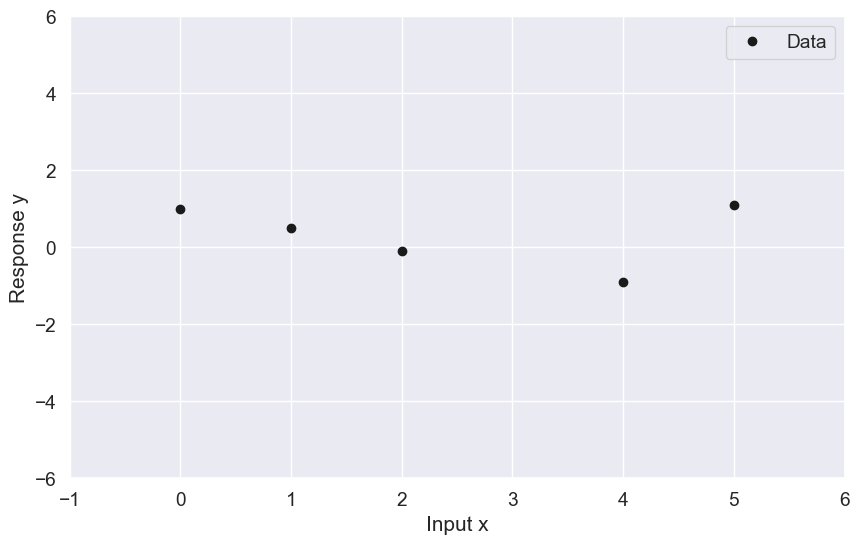

In [64]:
N = 5

xtrain = jnp.array([0,1,2,4,5])[:, None]
ytrain = jnp.array([1,0.5,-0.1,-0.9,1.1])[:, None]

# plot
def plot_toydata(ax):
    ax.plot(xtrain, ytrain, 'k.', label='Data', markersize=12)
    ax.set(xlabel='Input x', ylabel='Response y', xlim=(-1, 6), ylim=(-6, 6))
    ax.legend()

fig, ax = plt.subplots(1,1, figsize=(10, 6))
plot_toydata(ax)

In [65]:
# Write design matrix
def design_matrix(x):
    return jnp.column_stack((jnp.ones(len(x)), x,x**2,x**3))

alpha = 0.5 #prior precision
sigma = 1/5 #beta = 1/ sigma^2
beta = 1 / sigma**2

Phi_train = design_matrix(xtrain)
model = BayesianLinearRegression(Phi_train, y=ytrain, alpha=alpha, beta=1/sigma**2)  



# $w_{MLE}$ and $w_{MAP}$

In [66]:
w_MLE = jnp.linalg.solve(Phi_train.T@Phi_train, Phi_train.T@ytrain).ravel()
w_MAP = (beta*jnp.linalg.solve(alpha*jnp.identity(Phi_train.shape[1]) + beta*(Phi_train.T@Phi_train), Phi_train.T)@ytrain).ravel()

w_MLE,w_MAP

(Array([ 0.9533578 ,  0.266476  , -0.69328845,  0.12892307], dtype=float32),
 Array([ 0.9470227 ,  0.2469165 , -0.6790359 ,  0.12686162], dtype=float32))

# Posterior mean and covaraince matrix

In [68]:
model.compute_posterior(alpha = alpha, beta = beta)

(Array([[ 0.9470227 ],
        [ 0.2469165 ],
        [-0.6790359 ],
        [ 0.12686162]], dtype=float32),
 Array([[ 0.03658523, -0.04402104,  0.01481672, -0.00149987],
        [-0.04402107,  0.13294227, -0.06430131,  0.00799767],
        [ 0.01481677, -0.06430135,  0.03584182, -0.00480549],
        [-0.00149988,  0.00799768, -0.0048055 ,  0.00066975]],      dtype=float32))

# Predict new point

In [72]:
xstar = jnp.array([3]) #new point 
model.predict_y(Phi = design_matrix(xstar))

(Array([-0.99828744], dtype=float32), Array([0.073962], dtype=float32))